# Nonlinear Prediction
Yet again, we consider the Hénon map
$$\begin{align}X_{n+1} &= 1-aX_n^2+bY_n \\
Y_{n+1} &= X_n,\end{align}$$
with $a = 1.4$ and $b=0.3$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def henon_map(x, y, a=1.4, b=0.3):
    x_new = 1 - (a * x**2) + (b * y)
    y_new = x
    return x_new, y_new

def henon_series(x0, y0, n, a=1.4, b=0.3):
    xs = [x0]
    ys = [y0]
    for _ in range(n):
        x_new, y_new = henon_map(xs[-1], ys[-1], a, b)
        xs.append(x_new)
        ys.append(y_new)
    return xs, ys

def henon_map_iterations(x0, y0, n_total, n_skip, a=1.4, b=0.3):
    xs, ys = henon_series(x0, y0, n_total, a=a, b=b)
    return xs[n_skip:], ys[n_skip:]

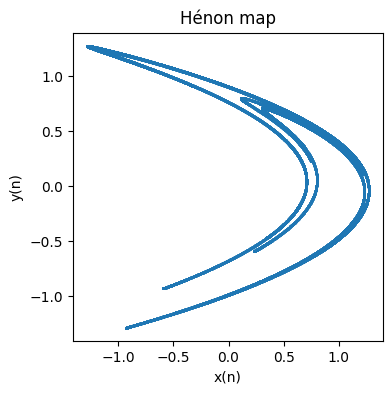

In [3]:
xs, ys = henon_map_iterations(0, 0, 100000, 2000)
xs = np.asarray(xs)
ys = np.asarray(ys)

plt.figure(figsize=(4, 4))
plt.plot(xs, ys, '.', markersize=1)
plt.xlabel('x(n)')
plt.ylabel('y(n)')
plt.axis('equal')
plt.title('Hénon map')
plt.show()

### 2D delay embedding
We will compare the above with the plot of $X_n$ versus $X_{n-1}$ to diagnose the structure in dynamics, which essentially reveals the same topology as the original data to the pure delay nature of the underlying dynamical law.

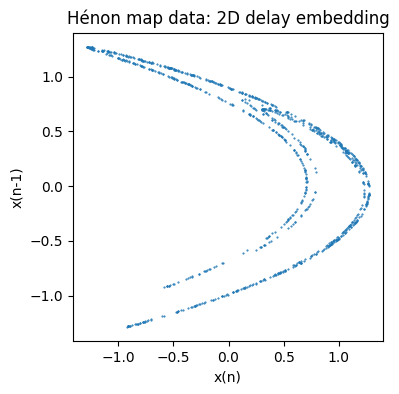

In [4]:
# time delay embedding with m=2, tau=1
plt.figure(figsize=(4, 4))
plt.plot(xs[1:1000], xs[:999], '.', markersize=1)
plt.xlabel('x(n)')
plt.ylabel('x(n-1)')
plt.title('Hénon map data: 2D delay embedding')
plt.show()

In [5]:
xtrain = xs[:1000] # for training
xpred = xs[1000:1010] # for prediction testing

### Prediction using time-delay embeddings
We will take the "vanilla" $m$-dimensional delay embedding, i.e., $(X_n, X_{n-1}, \ldots, X_{n-m+1})$, and use uniform state-space averaging by relying on $k$-nearest neighbors in the $m$-dimensional space to predict the future of the time series.

In [6]:
def knn_predictor(x, k=8, m=2):
    x = np.asarray(x, dtype=float)
    N = len(x)
    assert ((N-m >= k >= 1) and (m > 0)), 'invalid k or m'
    last = x[-m:] # target state [X_{N-m+1}, ..., X_N]

    # build statespace and deltas
    states = []
    deltas = []
    for n in range(N-m):
        state = x[n:n+m] # candidate state [X_{n-m+1}, ..., X_n]
        states.append(state)
        deltas.append(x[n+m] - x[n+m-1]) # next iteration delta

    states = np.asarray(states)
    deltas = np.asarray(deltas)

    # compute distances to target state and sort to find k nearest neighbors
    d2 = np.sum((states - last) ** 2, axis=1)
    order = np.argsort(d2)[:k]

    # return prediction as average of k nearest neighbor deltas
    return x[-1] + np.mean(deltas[order])

In [7]:
x1001_pred = knn_predictor(xtrain, k=8, m=2)
print(f'actual X_1001 = {xpred[0]:.8f}')
print(f'predicted X_1001 = {x1001_pred:.8f}')
print(f'absolute error   = {abs(x1001_pred - xpred[0]):.8f}')

actual X_1001 = 0.67673960
predicted X_1001 = 0.69835519
absolute error   = 0.02161559


In [8]:
def iterated_predictor(x, n_steps, k=8, m=2):
    x = np.asarray(x, dtype=float)
    preds = []
    for _ in range(n_steps):
        x_next = knn_predictor(x, k=k, m=m)
        preds.append(x_next)
        x = np.append(x, x_next) # add predicted value to the end of the series
    return np.asarray(preds)

In [9]:
preds = iterated_predictor(xtrain, n_steps=xpred.size, k=8, m=2)
errors = np.abs(preds - xpred)

print('n       predicted        actual        abs error')
for j in range(xpred.size):
    n = 1001 + j
    print(f'{n:4d}   {preds[j]:12.8f}   {xpred[j]:12.8f}   {errors[j]:10.8f}')

n       predicted        actual        abs error
1001     0.69835519     0.67673960   0.02161559
1002     0.41616116     0.41520140   0.00095976
1003     0.95068333     0.96167280   0.01098947
1004    -0.15266207    -0.17017999   0.01751792
1005     1.25571577     1.24795612   0.00775965
1006    -1.24103798    -1.23140627   0.00963172
1007    -0.77882870    -0.74851911   0.03030959
1008    -0.21754444    -0.15381509   0.06372936
1009     0.69802525     0.74232155   0.04429631
1010     0.24249071     0.18239767   0.06009304


To test the quality of prediction further, we will continue predicting for the next 50 timesteps.

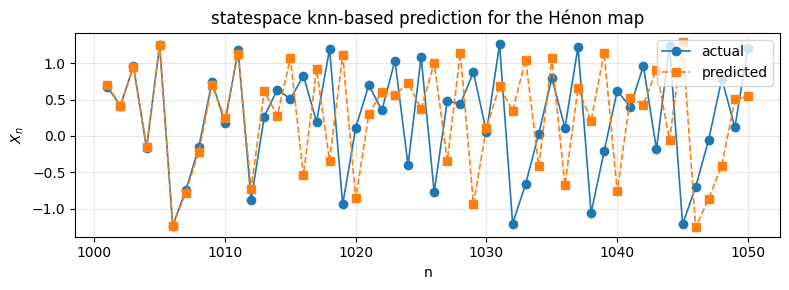

In [10]:
# longer prediction to see growth of error
import locale
xpred_ext = xs[1000:1050]
preds_ext = iterated_predictor(xtrain, n_steps=xpred_ext.size, k=8, m=2)
ns_pred = np.arange(1001, 1001 + xpred_ext.size)

plt.figure(figsize=(8, 3))
plt.plot(ns_pred, xpred_ext, 'o-', lw=1.2, label='actual')
plt.plot(ns_pred, preds_ext, 's--', lw=1.2, label='predicted')
plt.xlabel('n')
plt.ylabel(r'$X_n$')
plt.title('statespace knn-based prediction for the Hénon map')
plt.grid(alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

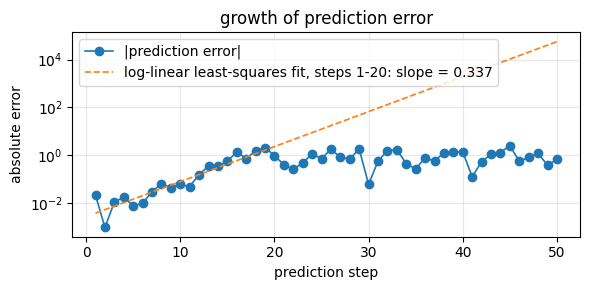

fitted exponential growth rate over steps 1-20: 0.336824


In [11]:
# compare growth of the absolute prediction error with an exponential fit
errors = np.abs(preds_ext - xpred_ext)
steps = np.arange(1, len(errors) + 1)

# choose a range where log(error) looks approximately linear
fit_lo = 1
fit_hi = 20

fit_mask = (steps >= fit_lo) & (steps <= fit_hi)
fit_steps = steps[fit_mask]
fit_errors = errors[fit_mask]

# avoid log(0)
valid = fit_errors > 0
fit_steps = fit_steps[valid]
fit_errors = fit_errors[valid]

# ordinary least-squares fit to log(error) = c + lambda * n
fit_coef = np.polyfit(fit_steps, np.log(fit_errors), 1)
fit_slope = fit_coef[0]
fit_intercept = fit_coef[1]

# fitted exponential over all steps
fit_line = np.exp(fit_intercept + fit_slope * steps)

plt.figure(figsize=(6, 3))
plt.semilogy(steps, errors, 'o-', lw=1.2, label='|prediction error|')
plt.semilogy(
    steps, fit_line, '--', lw=1.2,
    label=fr'log-linear least-squares fit, steps {fit_lo}-{fit_hi}: slope = {fit_slope:.3f}'
)
plt.xlabel('prediction step')
plt.ylabel('absolute error')
plt.title('growth of prediction error')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'fitted exponential growth rate over steps {fit_lo}-{fit_hi}: {fit_slope:.6f}')

For a chaotic system, the prediction error is expected to grow as $|e_n| \sim e^{\lambda_1 n}$, where $\lambda_1 \approx 0.419$ for the Hénon map. Above is the empirical ballpark estimate which roughly matches the expected range for $\lambda_1$, and it may improve with a larger `xtrain` dataset.

### Optimal prediction under noisy measurements
We will add a small, independent measurement noise to the dataset and check the prediction quality over the first 15 steps of the test dataset `xpred`, and search over values of $k$ and $m$ to find the optimal predictor. Note that the optimal chosen values may change significantly on each repeat, since we do not deal with multiple training datasets at once.

In [24]:
rng = np.random.default_rng(0)
x_noisy = xs + 0.01 * np.random.randn(len(xs)) # sigma = 0.01
xtrain = x_noisy[:1000]
xpred = x_noisy[1000:1015]

# rmse metric for evaluation
def prediction_error(preds, truth):
    return np.sqrt(np.mean((preds - truth)**2))

# search over k and m
k_values = [2, 4, 6, 8, 10, 12]
m_values = [2, 3, 4, 5]
results = []
for m in m_values:
    for k in k_values:
        preds = iterated_predictor(xtrain, n_steps=xpred.size, k=k, m=m)
        err = prediction_error(preds, xpred)
        results.append((k, m, err))

# sort by error
results_sorted = sorted(results, key=lambda x: x[2])
opt_k, opt_m, opt_err = results_sorted[0]
print(f'optimal k = {opt_k}, m = {opt_m}, RMSE = {opt_err:.6f}')

optimal k = 8, m = 3, RMSE = 0.028313


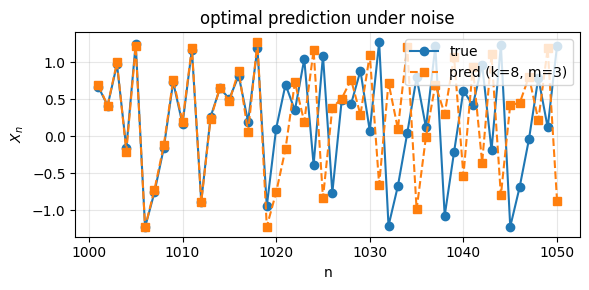

In [25]:
opt_preds = iterated_predictor(xtrain, 50, k=opt_k, m=opt_m)
steps = np.arange(1, 51)
plt.figure(figsize=(6,3))
plt.plot(np.arange(1001, 1051), x_noisy[1000:1050], 'o-', label='true')
plt.plot(np.arange(1001, 1051), opt_preds, 's--', label=f'pred (k={opt_k}, m={opt_m})')
plt.xlabel('n')
plt.ylabel(r'$X_n$')
plt.title('optimal prediction under noise')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()